# Sistema de Soporte a la Decisión (DSS)

Etapa 1 - Segmentar conforme a la ubicación y el precio de mercado. Las características físicas van a permitir diferenciar los tipos de inmueble dentro de cada nivel de mercado.

Etapa 2 — Predicción de precio conforme a las Dimensiones, Habitaciones, Baños, Estacionamiento y Pisos toman todo el protagonismo.
Dentro de cada cluster ya sabes en qué segmento de mercado estás, y el modelo predice el precio exacto según las características físicas del inmueble específico.

Etapa 3 — Optimización, se toma el precio predicho y lo ajusta según restricciones financieras del proyecto.

# Segmentación de inmuebles.

**Objetivo:**

Segmentar inmuebles considerando simultáneamente sus características físicas y el contexto económico-geográfico en el que se ubican.

**Data:**

Los datos de los precios y características de los inmuebles fueron obtenidos de portales públicos inmobiliarios mediante técnicas de web scraping, considerando únicamente información visible sin autenticación. 

- ... registros de inmuebles recabados en los primeros meses del año 2026.
- Columnas:
    >*Estado* <br>
    *Municipio* <br>
    *Colonia* <br>
    *Precio* <br>
    *Dimensiones* <br>
    *Habitaciones* <br>
    *Baños* <br>
    *Tipo* <br>
    *Estacionamiento* <br>
    *Pisos* <br>
    *Link* <br>
    *TC* <br>
    *Fecha de recolección los datos*

## Obtención de datos

Usos de web scraping para obtener datos de propiedades en venta desde Mercado Libre. Automatiza la recolección de información como precio, dimensiones, número de habitaciones y enlace del anuncio, para poder analizar el mercado inmobiliario sin tener que recopilar los datos manualmente. 

In [1]:
# Librerias

import warnings
import datetime
import folium
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from scipy.spatial.distance import mahalanobis
from forex_python.converter import CurrencyRates
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew, boxcox, yeojohnson
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score

## Carga y Limpieza

##### Carga y limpieza inicial

Elimina los links que esten repetidos para evitar duplicados de inmuebles.

In [ ]:
### ---- DATA
df = pd.read_excel("datos.xlsx")
print(f'Registros iniciales; {len(df)}')
df = df.drop_duplicates(subset=["Link"])
df.head()
print(f'Registros después de duplicados; {len(df)}')

Estado             11690
Municipio          11363
Colonia            11362
Precio             11690
Dimensiones        11363
Habitaciones       11363
Baños              11363
Tipo               11690
Estacionamiento    11363
Pisos              11523
Link               11690
TC                   521
Fecha              11690
dtype: int64
Estado             10519
Municipio          10304
Colonia            10304
Precio             10519
Dimensiones        10304
Habitaciones       10304
Baños              10304
Tipo               10519
Estacionamiento    10304
Pisos              10423
Link               10519
TC                   472
Fecha              10519
dtype: int64


##### Conversión de moneda

Los inmuebles publicados en USD fueron convertidos a MXN para tener todo el data en pesos. Mediante una librería se obtiene el tipo de cambio al primero del mes que se realizó el scraping y se convierten únicamente los registros con información en TC.

In [3]:
### ---- CONVERSIÓN DE MONEDA CON TC FIJO POR MES
c = CurrencyRates()

# Diccionario de meses
meses = {
    "Ene": 1, "Feb": 2, "Mar": 3, "Abr": 4, "May": 5, "Jun": 6,
    "Jul": 7, "Ago": 8, "Sep": 9, "Oct": 10, "Nov": 11, "Dic": 12
}

# 🔑 cache de tasas
tasas_cache = {}

# Contar cuántas filas están en US
filas_usd = df["TC"].str.upper() == "US"
cantidad_usd = filas_usd.sum()
print(f"Filas en USD encontradas: {cantidad_usd}")

def convertir_precio(row):
    if str(row["TC"]).upper() == "US":
        try:
            mes_abrev, año_str = row["Fecha"].split("-")
            mes_num = meses[mes_abrev]
            año_num = 2000 + int(año_str)
            fecha_tc = datetime.date(año_num, mes_num, 1)

            if fecha_tc not in tasas_cache:
                tasas_cache[fecha_tc] = c.get_rate("USD", "MXN", fecha_tc)

            tasa = tasas_cache[fecha_tc]

            row["Precio"] = float(row["Precio"]) * tasa

        except Exception as e:
            print(f"Error en fila {row.name}: {e}")
    return row

df = df.apply(convertir_precio, axis=1)

Filas en USD encontradas: 472


##### Diagnostico inicial de nulos

Se eliminan variables como Link, TC y Fecha debido a que no contienen información relevante para la segmentación del mercado inmobiliario y podrían introducir ruido en el modelo.

In [4]:
### ---- DIAGNOSTICO DE NULOS Y ELIMINACION DE COLUMNAS
registros_antes = len(df)

print(df.isnull().mean()*100)

# Columnas que no aportan al modelo
df = df.drop(columns=['Link', 'TC', 'Fecha'])

# Filtrar valores 
df = df[df["Precio"] > 0]
df = df[df["Dimensiones"] > 0]

# Eliminar valores nulos
df = df.dropna()
registros_despues = len(df) 

print(f"Registros antes:  {registros_antes:,}")
print(f"Registros después: {registros_despues:,}")
print(f"Eliminados:        {registros_antes - registros_despues:,} ({(registros_antes - registros_despues)/registros_antes*100:.1f}%)")

Estado              0.000000
Municipio           2.043921
Colonia             2.043921
Precio              0.000000
Dimensiones         2.043921
Habitaciones        2.043921
Baños               2.043921
Tipo                0.000000
Estacionamiento     2.043921
Pisos               0.912634
Link                0.000000
TC                 95.512881
Fecha               0.000000
dtype: float64
Registros antes:  10,519
Registros después: 10,304
Eliminados:        215 (2.0%)


## Análisis de la información

##### Coberturra Geográfica

In [5]:
print(f"Estados únicos:    {df['Estado'].nunique()}")
print(f"Municipios únicos: {df['Municipio'].nunique()}")
print(f"Colonias únicas:   {df['Colonia'].nunique()}")

print("\n--- Registros por Tipo ---")
print(df['Tipo'].value_counts())

Estados únicos:    32
Municipios únicos: 390
Colonias únicas:   2989

--- Registros por Tipo ---
Tipo
Casa            6058
Departamento    4246
Name: count, dtype: int64


In [6]:
print("--- Registros por Estado (Top 15) ---")
df['Estado'].value_counts().head(15)

--- Registros por Estado (Top 15) ---


Estado
CDMX                614
Jalisco             545
Estado de Mexico    458
Nuevo Leon          420
Guerrero            418
Tamaulipas          414
Morelos             403
Michoacan           359
Quintana Roo        358
Queretaro           343
Puebla              338
Oaxaca              335
Veracruz            328
Coahuila            326
Yucatan             316
Name: count, dtype: int64

In [7]:
df.groupby('Estado')['Tipo'].value_counts()

Estado               Tipo        
Aguascalientes       Casa            133
                     Departamento    119
Baja California      Casa            134
                     Departamento    111
Baja California Sur  Casa            128
                                    ... 
Veracruz             Casa            157
Yucatan              Casa            158
                     Departamento    158
Zacatecas            Casa            143
                     Departamento     21
Name: count, Length: 64, dtype: int64

##### Variables de Mercado

**Crear variable "Zona"**

Para incorporar el efecto de la ubicación y relacionarlo con el precio se creo la variable combinando Estado y Municipio. No se va a incorporar la colonia al crear la variable,ya que se extendería el número de variables y no hay la misma cantidad de información por estado por lo que quedaría desbalanceado.

In [8]:
### ---- ZONA (ESTADO + MUNICIPIO)
df["Zona"] = df["Estado"] + " - " + df["Municipio"]

print("\n--- Zonas con más registros (Top 20) ---")
df['Zona'].value_counts().tail(20)


--- Zonas con más registros (Top 20) ---


Zona
Queretaro - Pedro Escobedo          1
CDMX - Paseos de Taxqueña           1
Oaxaca - Tlalixtac De Cabrera       1
Oaxaca - Mazunte                    1
Michoacan - Epitacio Huerta         1
Michoacan - Zitacuaro               1
CDMX - San Jeronimo Aculco          1
Morelos - cuautla                   1
Nayarit - Del Nayar                 1
Nuevo Leon - Pesqueria              1
Nuevo Leon - Allende                1
Nuevo Leon - General Zuazua         1
CDMX - Residencial Zacatenco        1
CDMX - Pedregal de Santo Domingo    1
Oaxaca - Tlacolula de Matamoros     1
Oaxaca - Puerto Escondido           1
Oaxaca - San Bartolo Coyotepec      1
Oaxaca - San Miguel del Puerto      1
Oaxaca - San Pablo Etla             1
CDMX - Tlahuac                      1
Name: count, dtype: int64

In [9]:
df['Zona'].value_counts()

Zona
Guerrero - Acapulco               369
Michoacan - Morelia               296
Sinaloa - Mazatlan                266
Yucatan - Merida                  257
Queretaro - Queretaro             239
                                 ... 
Oaxaca - Puerto Escondido           1
Oaxaca - San Bartolo Coyotepec      1
Oaxaca - San Miguel del Puerto      1
Oaxaca - San Pablo Etla             1
CDMX - Tlahuac                      1
Name: count, Length: 406, dtype: int64

Se incorporó una variable para representar los precios en relación a su ubicación, utilizando la mediana de la zona. Ya que al usar la mediana, los clusters se basan en el comportamiento central del mercado sin que los extremos distorsionen la comparación.

In [10]:
### ---- PRECIO MEDIANO POR NIVEL GEOGRÁFICO

mediana_estado_eda    = df.groupby('Estado')['Precio'].median()
mediana_municipio_eda = df.groupby('Municipio')['Precio'].median()
mediana_zona_eda      = df.groupby('Zona')['Precio'].median()
oferta_zona_eda       = df.groupby('Zona')['Precio'].count()

df['_Precio_mediana_zona_eda'] = df['Zona'].map(mediana_zona_eda)
df['_Oferta_zona_eda']         = df['Zona'].map(oferta_zona_eda)

La gráfica de la izquierda, analiza el precio mediano por estado con el objetivo de identificar diferencias regionales en el mercado inmobiliario. La de la derecha, analiza la distribución del número de inmuebles por zona con el fin de evaluar la representatividad de los datos a nivel geográfico.

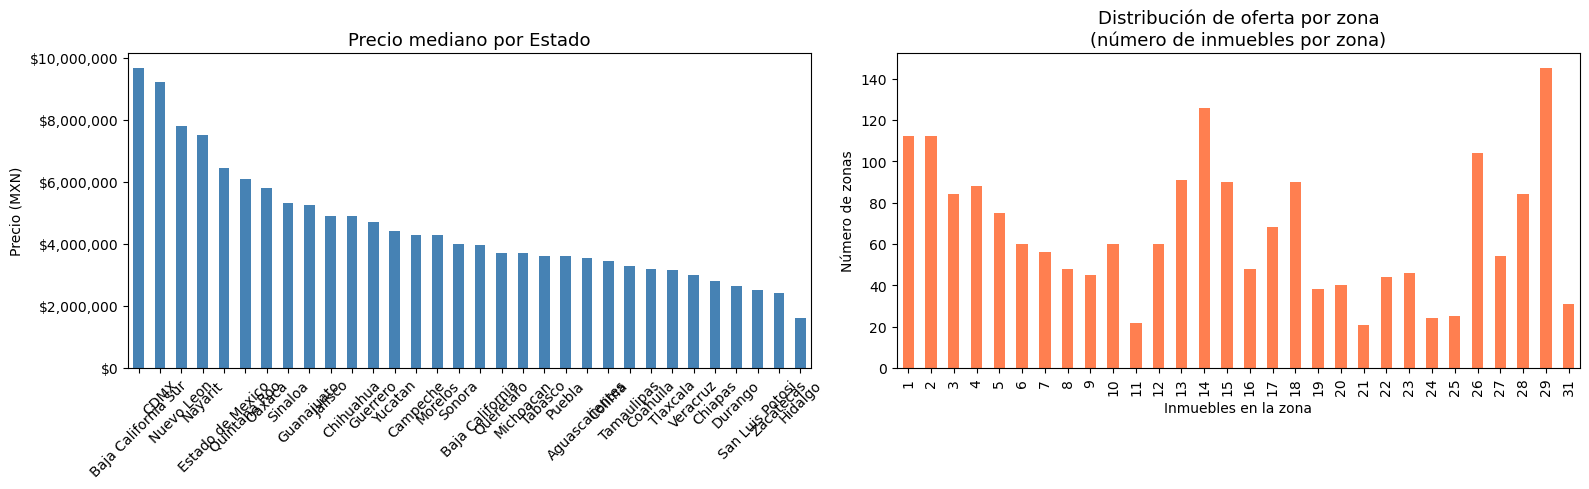


Registros en zonas con menos de 5 inmuebles: 396


In [11]:
### ---- GRAFICA DISTRIBUCION DE PRECIOS
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Precio mediano por estado
medianas_estado = df.groupby('Estado')['Precio'].median().sort_values(ascending=False)
medianas_estado.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Precio mediano por Estado', fontsize=13)
axes[0].set_ylabel('Precio (MXN)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Distribución de oferta por zona
df['_Oferta_zona_eda'].value_counts().sort_index().head(30).plot(
    kind='bar', ax=axes[1], color='coral'
)
axes[1].set_title('Distribución de oferta por zona\n(número de inmuebles por zona)', fontsize=13)
axes[1].set_xlabel('Inmuebles en la zona')
axes[1].set_ylabel('Número de zonas')

plt.tight_layout()
plt.show()

zonas_pocas = (df['_Oferta_zona_eda'] < 5).sum()
print(f"\nRegistros en zonas con menos de 5 inmuebles: {zonas_pocas:,}")

Se eliminan dichas columnas ya que fueron creadas únicamente para visualizar patrones iniciales.

In [12]:
# Limpiar columnas temporales del EDA — se recalcularán correctamente en preprocesamiento
df = df.drop(columns=['_Precio_mediana_zona_eda', '_Oferta_zona_eda'])
print("Columnas temporales eliminadas. Shape del df:", df.shape)

Columnas temporales eliminadas. Shape del df: (10304, 11)


##### Distribución de variables numéricas

La mayoría de las variables estan sesgadas a la derecha, indicando una concentración en los valores bajos. Lo que quiere decir que predominan inmuebles de tamaño y precio medio en proporcion a las propiedades de alto valor y tamaño.

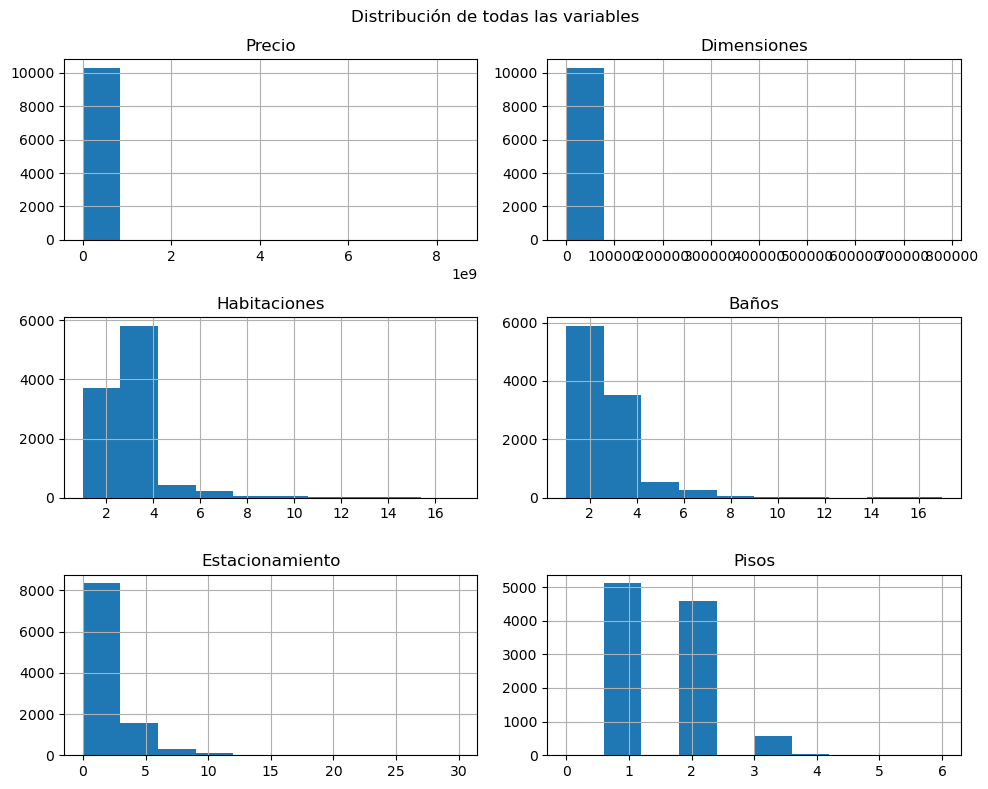

In [13]:
### ---- HISTOGRAMAS
df.hist(figsize=(10, 8))
plt.suptitle('Distribución de todas las variables')
plt.tight_layout()
plt.show()

In [14]:
### ---- DESCRIPCION DE ESTADISTICAS
df.describe().round(2)

,Precio,Dimensiones,Habitaciones,Baños,Estacionamiento,Pisos
count,1.030400e+04,10304.00,10304.00,10304.00,10304.00,10304.00
mean,9.138359e+06,477.22,2.95,2.60,1.99,1.57
std,8.669992e+07,9617.12,1.29,1.46,1.76,0.63
min,2.976600e+04,2.00,1.00,1.00,0.00,0.00
25%,2.550000e+06,95.00,2.00,2.00,1.00,1.00
50%,4.289500e+06,150.00,3.00,2.00,2.00,2.00
75%,7.950000e+06,284.00,3.00,3.00,2.00,2.00
max,8.495000e+09,780000.00,17.00,17.00,30.00,6.00


##### Correlación entre variables

Debido a la heterogeneidad y polarización del mercado inmobiliario nacional, no se espera correlación alta entre las variables numéricas. Esto se debe a que el valor de los inmuebles esta mayor condicionado por su ubicación y no tanto en sus características físicas como tamaño o número de habitaciones.

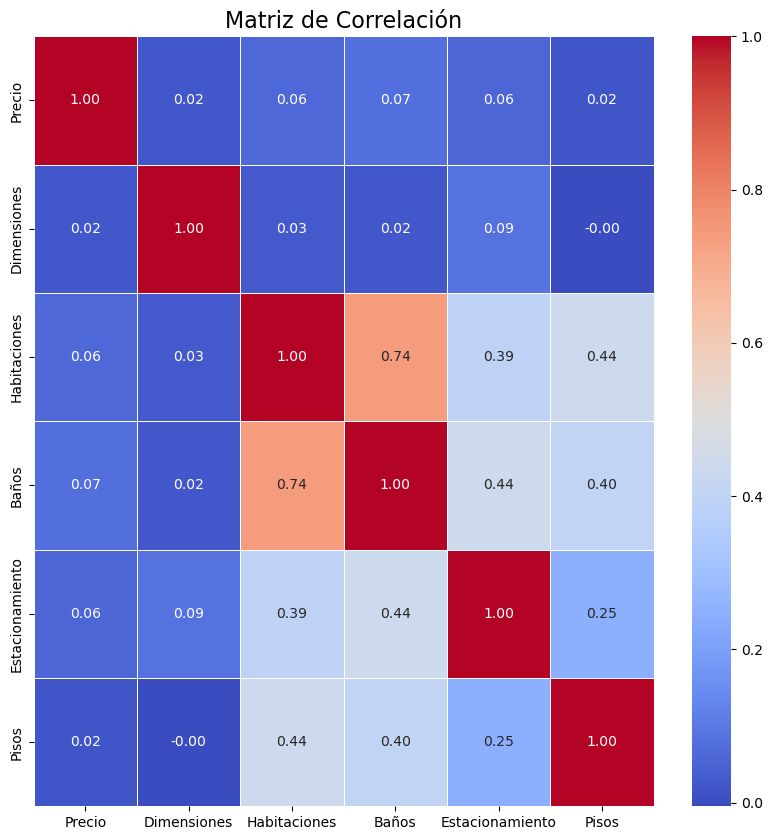

In [15]:
### ---- MATRIZ DE CORRELACIÓN
matriz_corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,10))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación', fontsize=16)
plt.show()

A pesar de tener una alta correlación entre las habitaciones y los baños, no se observa multicolinealidad severa por lo que no es estictamente necesario utilizar un PCA en este modelo, para preservar la interpretabilidad de sus variables.

## Inmuebles atípicos

Después de ver las distribuciones se esperan varios outliers, dada la heterogeneidad del mercado inmobiliario (clase social, zona, tipo de inmueble).

Los datos  atípicos se van a detectar con dos métodos complementarios: Modified Z-Score para outliers univariantes y Distancia de Mahalanobis para outliers multivariantes.

Con este último se hace una detección de inmuebles atípicos que son realmente “raros”. Por ejemplo, un departamento gigante y carísimo en una zona popular.

In [16]:
### ---- OUTLIERS
variables_num = [
    "Precio",
    "Dimensiones",
    "Habitaciones",
    "Baños",
    "Estacionamiento",
    "Pisos"]

# Modified Z-Score — detecta outliers por variable individual
def detect_outliers_modified_zscore(series, threshold=3.5):
    median = series.median()
    mad = np.median(np.abs(series - median))
    modified_z = 0.6745 * (series - median) / mad
    return np.abs(modified_z) > threshold

# Mahalanobis — detecta outliers considerando todas las variables juntas
def detect_outliers_mahalanobis(df, vars_list, significance_level=0.01):
    X = df[vars_list].values
    mean = X.mean(axis=0)
    cov = np.cov(X, rowvar=False)
    inv_cov = np.linalg.inv(cov)
    # IMPORTANTE: Se eleva al cuadrado para obtener la distancia de Mahalanobis real (D²)
    m_dist_sq = np.array([mahalanobis(x, mean, inv_cov)**2 for x in X])
    # UMBRAL ESTADÍSTICO REAL: Distribución Chi-cuadrada
    degrees_of_freedom = len(vars_list)
    threshold = stats.chi2.ppf(1 - significance_level, df=degrees_of_freedom)
    outliers_mask = m_dist_sq > threshold
    return outliers_mask, m_dist_sq, threshold

# Outliers univariantes por variable
outliers_uni = {col: detect_outliers_modified_zscore(df[col]) for col in variables_num}
# Outliers multivariantes
outliers_multi, m_dist_sq, threshold = detect_outliers_mahalanobis(df, variables_num)


print(f"Outliers Univariantes combinados (Modified Z-Score): {np.any(np.column_stack(list(outliers_uni.values())), axis=1).sum()}")
print(f"Umbral Estadístico Mahalanobis Real (Chi²): {threshold:.2f}")
print(f"Outliers Multivariantes Detectados (Mahalanobis): {outliers_multi.sum()}")

Outliers Univariantes combinados (Modified Z-Score): 1712
Umbral Estadístico Mahalanobis Real (Chi²): 16.81
Outliers Multivariantes Detectados (Mahalanobis): 359


Como se observa en los resultados de modified z-score, se identificaron ... observaciones atípicas en al menos una variable. Sin embargo,con la distancia de Mahalonobis, sólo ... observaciones presentan patrones multivariantes atípicos considerando simultáneamente todas las características del inmueble.

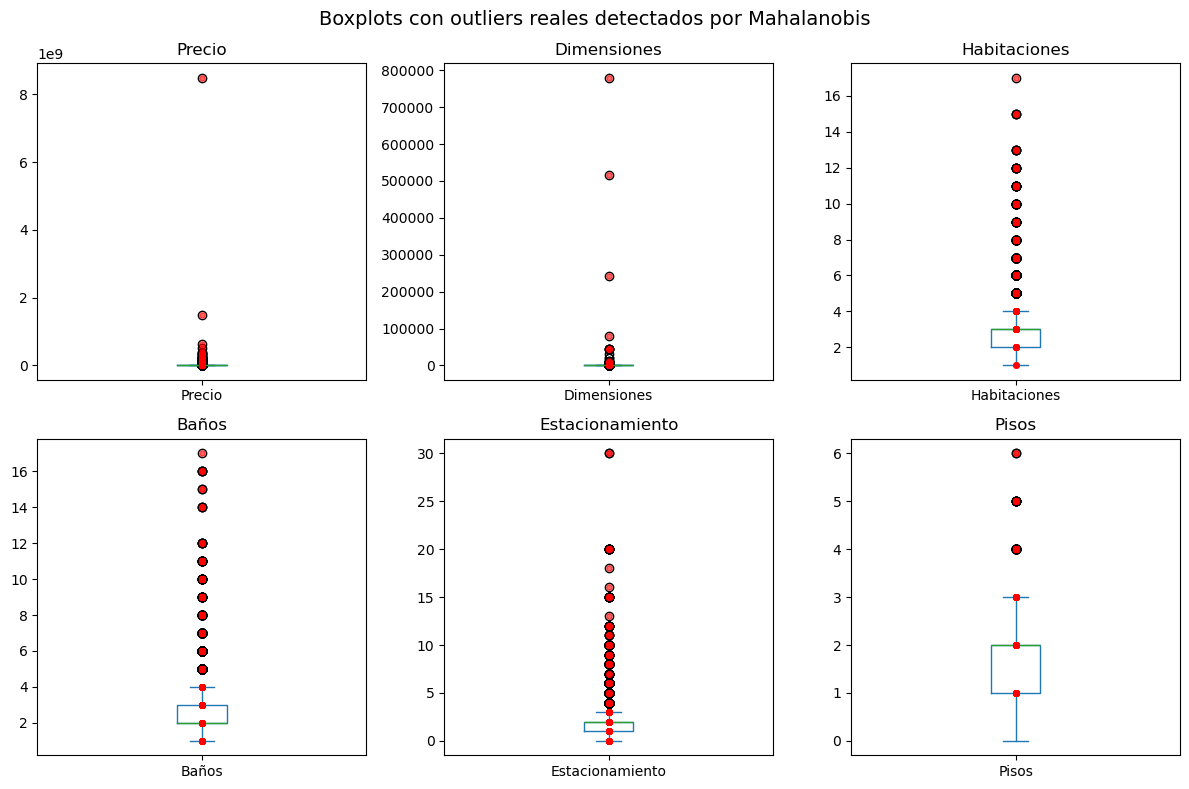

In [17]:
### ---- Boxplots con outliers Mahalanobis
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(variables_num):
    ax = axes[i]
    df[col].plot(kind='box', ax=ax)
    
    # Filtrar los valores detectados por la máscara multivariante
    outliers_values = df[col][outliers_multi]
    
    # Dibujar los puntos rojos sobre el boxplot
    ax.scatter(np.ones(outliers_values.shape[0]), outliers_values, color='red', alpha=0.6, s=15, zorder=3)
    ax.set_title(col)

plt.suptitle('Boxplots con outliers reales detectados por Mahalanobis', fontsize=14)
plt.tight_layout()
plt.show()

Aunque se identifican observaciones atípicas, debido a la naturaleza heterogénea del mercado inmobiliario, estos no se eliminan ya que representan segmentos reales del mercado.


## Transformaciones

Se probaron distintos métodos de transformación para saber cuál reduce más el sesgo dependiendo a la variable.

In [18]:
### ---- TRANSFORMACIONES
print(f"{'Variable':<15} {'Original':>10} {'Log':>10} {'Sqrt':>10} {'Box-Cox':>10} {'Yeo-J':>10}")
print("-" * 75)

for col in variables_num:
    data_col = df[col].dropna()
    original         = skew(data_col)
    log_skew         = skew(np.log1p(data_col))
    sqrt_skew        = skew(np.sqrt(data_col))
    try:
        bc, _ = boxcox(data_col + 1)
        bc_skew = skew(bc)
    except ValueError:
        bc_skew = np.nan
    yj, _ = yeojohnson(data_col)
    yj_skew = skew(yj)

    print(f"{col:<15} {original:>10.2f} {log_skew:>10.2f} {sqrt_skew:>10.2f} {bc_skew:>10.2f} {yj_skew:>10.2f}")

Variable          Original        Log       Sqrt    Box-Cox      Yeo-J
---------------------------------------------------------------------------
Precio               91.62       0.50      15.79      -0.03      -0.03
Dimensiones          68.38       1.20      29.63      -0.06      -0.06
Habitaciones          2.13       0.13       0.67      -0.01      -0.01
Baños                 2.14       0.41       0.83       0.02       0.02
Estacionamiento       4.04       0.19       0.24      -0.02      -0.02
Pisos                 0.86       0.39       0.47       0.13       0.13


Solamente se aplicó transformación Box-Cox al precio y las dimensiones porque son las únicas con sesgo relevante. Las demás varoables al ser discretas y tranformarlas dificultaría su interpretación.

In [19]:
# Aplicar la transformación Box-Cox 
df["bc_Precio"], _      = boxcox(df["Precio"])
df["bc_Dimensiones"], _ = boxcox(df["Dimensiones"])

print("Sesgo post-transformación:")
print(f"  Transformada Precio:       {skew(df['bc_Precio']):.3f}")
print(f"  Transformada Dimensiones:  {skew(df['bc_Dimensiones']):.3f}")


Sesgo post-transformación:
  Transformada Precio:       -0.031
  Transformada Dimensiones:  -0.081


## Preprocesamiento

#### Split Train/Test

Se va a dividir el dataset para hacer una comparación del modelo. Train para aprender los centroides y las medianas de zona, y test para verificar que los clusters son estables

In [20]:
### ---- SPLIT-TEST
train, test = train_test_split(df,test_size=0.2,random_state=42,
    stratify=df['Tipo'] #para que tengan la misma proporción según el tipo
)

df_train = train.copy().reset_index(drop=True)
df_test  = test.copy().reset_index(drop=True)

#### Separación de por tipo

Debido a que casas y departamentos presentan distribuciones distintas, se construyeron modelos de clustering independientes para cada tipo de inmueble con el fin de obtener segmentos más homogéneos y comparables. Ya que las características físicas, la distribución de espacios y la relación entre dimensiones, habitaciones y servicios pueden tener comportamientos distintos según el tipo de propiedad.

In [21]:
# -- Separar por tipo en TRAIN 
df_casas_train  = df_train[df_train['Tipo'] == 'Casa'].copy()
df_deptos_train = df_train[df_train['Tipo'] == 'Departamento'].copy()

# -- Separar por tipo en TEST 
df_casas_test   = df_test[df_test['Tipo'] == 'Casa'].copy()
df_deptos_test  = df_test[df_test['Tipo'] == 'Departamento'].copy()

print(f"Train — Casas: {len(df_casas_train):,}  |  Departamentos: {len(df_deptos_train):,}")
print(f"Test  — Casas: {len(df_casas_test):,}   |  Departamentos: {len(df_deptos_test):,}")

Train — Casas: 4,846  |  Departamentos: 3,397
Test  — Casas: 1,212   |  Departamentos: 849


#### Variables de Mercado

Para aproximar el valor del mercado, se calculo el precio mediano por zona para representar de nivel más robusto, el nivel de precios característico de cada ubicación, contemplando una oferta suficiente del 7 inmuebles por zona. 

In [22]:
### ---- VARIABLES DE MERCADO 
umbral_zona = 7
umbral_municipio = 15

def generar_y_asignar_mercado(df_train_sub, df_test_sub, umbral_zona=umbral_zona, umbral_municipio=umbral_municipio):
    """
    Calcula las estadísticas sobre el subconjunto de TRAIN (ej. solo casas) 
    y las aplica tanto a ese TRAIN como a su respectivo TEST.
    """
    # Estadísticas del tipo de propiedad en TRAIN
    mediana_estado    = df_train_sub.groupby('Estado')['bc_Precio'].median()
    mediana_municipio = df_train_sub.groupby('Municipio')['bc_Precio'].median()
    mediana_zona      = df_train_sub.groupby('Zona')['bc_Precio'].median()
    oferta_zona_train = df_train_sub.groupby('Zona')['bc_Precio'].count()
    oferta_municipio  = df_train_sub.groupby('Municipio')['bc_Precio'].count()
    mediana_global    = df_train_sub['bc_Precio'].median() # Rescate final para evitar NaNs

    def procesar_split(df_split):
        df_out = df_split.copy()
        
        # Mapeos de control
        df_out['Oferta_zona'] = df_out['Zona'].map(oferta_zona_train).fillna(0)
        df_out['Oferta_municipio'] = df_out['Municipio'].map(oferta_municipio).fillna(0)
        df_out['Precio_mediana_zona'] = df_out['Zona'].map(mediana_zona)
        df_out['Precio_mediana_municipio'] = df_out['Municipio'].map(mediana_municipio)

        # Cascada de fallback
        def fallback(row):
            # Nivel 1: Zona
            if row['Oferta_zona'] >= umbral_zona and pd.notna(row['Precio_mediana_zona']):
                return row['Precio_mediana_zona'], 'Zona'
            # Nivel 2: Municipio
            if row['Oferta_municipio'] >= umbral_municipio and pd.notna(row['Precio_mediana_municipio']):
                return row['Precio_mediana_municipio'], 'Municipio'
            # Nivel 3: Estado
            if row['Estado'] in mediana_estado.index:
                return mediana_estado[row['Estado']], 'Estado'
            # Nivel 4: Rescate Global (Blindaje contra nulos)
            return mediana_global, 'Global'

        resultados = df_out.apply(fallback, axis=1)
        # Extraer el precio y el nivel de la tupla devuelta por fallback
        df_out['Precio_mercado_zona'] = [r[0] for r in resultados]
        df_out['Nivel_mediana'] = [r[1] for r in resultados]
        
        # Limpieza de columnas auxiliares
        df_out = df_out.drop(columns=['Oferta_zona', 'Oferta_municipio', 'Precio_mediana_zona', 'Precio_mediana_municipio'])
        return df_out

    # Retorna el train y test ya procesados de forma independiente
    return procesar_split(df_train_sub), procesar_split(df_test_sub)


# ─── APLICAR EL PROCESO POR SEPARADO ───

# Procesar bloque de CASAS
df_casas_train, df_casas_test = generar_y_asignar_mercado(df_casas_train, df_casas_test)

# Procesar bloque de DEPARTAMENTOS
df_deptos_train, df_deptos_test = generar_y_asignar_mercado(df_deptos_train, df_deptos_test)


# ─── DIAGNÓSTICOS DE CONTROL ───
print("="*10, "DIAGNÓSTICO: CASAS", "="*10)
print("Distribución de niveles en TEST:")
print(df_casas_test['Nivel_mediana'].value_counts())
print("\nPorcentaje de uso en TEST:")
print(round(df_casas_test["Nivel_mediana"].value_counts(normalize=True)*100, 2))

print("\n" + "="*10, "DIAGNÓSTICO: DEPARTAMENTOS", "="*10)
print("Distribución de niveles en TEST:")
print(df_deptos_test['Nivel_mediana'].value_counts())
print("\nPorcentaje de uso en TEST:")
print(round(df_deptos_test["Nivel_mediana"].value_counts(normalize=True)*100, 2))

========== DIAGNÓSTICO: CASAS ==========
Distribución de niveles en TEST:
Nivel_mediana
Zona         1092
Estado        112
Municipio       8
Name: count, dtype: int64

Porcentaje de uso en TEST:
Nivel_mediana
Zona         90.10
Estado        9.24
Municipio     0.66
Name: proportion, dtype: float64

========== DIAGNÓSTICO: DEPARTAMENTOS ==========
Distribución de niveles en TEST:
Nivel_mediana
Zona         786
Estado        59
Municipio      4
Name: count, dtype: int64

Porcentaje de uso en TEST:
Nivel_mediana
Zona         92.58
Estado        6.95
Municipio     0.47
Name: proportion, dtype: float64


#### Escalamiento

Antes de aplicar los algoritmos de clustering, las variables numéricas fueron estandarizadas mediante StandardScaler.

El escalador se ajusta utilizando únicamente el conjunto de entrenamiento y posteriormente se aplica la misma transformación al conjunto de prueba. De esta manera, se mantiene la separación entre ambos conjuntos y se evita utilizar información del test durante el entrenamiento.

In [23]:
# VARIABLES PARA CLUSTERING
features_clustering =  [
    'Precio_mercado_zona',#'Oferta_zona',
    'bc_Dimensiones','Habitaciones','Baños','Estacionamiento','Pisos'
]

# ESCALAMIENTO
scaler_casas  = StandardScaler()
scaler_deptos = StandardScaler()

X_casas_train  = scaler_casas.fit_transform(df_casas_train[features_clustering])
X_casas_test   = scaler_casas.transform(df_casas_test[features_clustering])

X_deptos_train = scaler_deptos.fit_transform(df_deptos_train[features_clustering])
X_deptos_test  = scaler_deptos.transform(df_deptos_test[features_clustering])

print("Resumen escalamiento - Casas")
display(pd.DataFrame(X_casas_train,columns=features_clustering).describe().loc[['mean', 'std']])

print("Resumen escalamiento - Departamentos")
display(pd.DataFrame(X_deptos_train,columns=features_clustering).describe().loc[['mean', 'std']])

Resumen escalamiento - Casas


,Precio_mercado_zona,bc_Dimensiones,Habitaciones,Baños,Estacionamiento,Pisos
mean,1.231207e-14,-6.422157e-16,1.114347e-16,2.785867e-17,4.691987e-17,-3.005804e-17
std,1.000103e+00,1.000103e+00,1.000103e+00,1.000103e+00,1.000103e+00,1.000103e+00


Resumen escalamiento - Departamentos


,Precio_mercado_zona,bc_Dimensiones,Habitaciones,Baños,Estacionamiento,Pisos
mean,3.274521e-15,1.734000e-15,1.673342e-17,-1.092901e-16,7.477746e-17,0.0
std,1.000147e+00,1.000147e+00,1.000147e+00,1.000147e+00,1.000147e+00,0.0


## Clustering

Para realizar la segmentación se utilizaron variables que representan tanto las características físicas de los inmuebles como el contexto económico del mercado en el que se encuentran. De esta manera, los clusters no se construyen únicamente a partir del tamaño o de las características físicas, sino que también consideran el nivel de precios característico de su ubicación.

Dado que casas y departamentos presentan patrones estructurales distintos, se desarrollaron procesos de segmentación independientes para cada tipo de inmueble.

- **KMeans++**: basado en centroides
- **Agglomerative Clustering**: clustering jerárquico
- **PCA**:
- **TSNE**:

La selección del número de clusters no se realizará únicamente a partir de una métrica estadística. Las métricas internas de validación:

- ***Elbow***: Mide la reducción de la variabilidad interna (Se busca el codo). 
- ***Silhouette***: Mide separación entre clusters. (Valor alto)
- ***Calinski-Harabasz***: Premia clusters compactos y separados. (Valor alto)
- ***Davies-Boouldin***: Mide similitud entre clusters. (Valor bajo)

Estos se utilizarán como criterios de referencia para evaluar la estructura de los datos pero ninguna de estas métricas por sí sola determina automáticamente el número final de clusters.

La selección final de k no se basó únicamente en el valor máximo o mínimo de una métrica, sino también en la granularidad de la segmentación, el tamaño de los grupos, su interpretabilidad y su utilidad para las etapas posteriores del DSS.

#### Clusters

Para evaluar diferentes valores de k se utilizaron cuatro criterios complementarios. El método del codo, la métrica Silhouette, el índice Calinski-Harabasz y Davies-Bouldin.

Se evaluaron distintas configuraciones de k entre 2 y 10 clusters con el fin de identificar estructuras potenciales en los datos. Posteriormente se seleccionó el número de clusters considerando simultáneamente métricas de calidad, interpretabilidad y tamaño de los segmentos obtenidos.

In [24]:
### ---- MÉTRICAS DE VALIDACIÓN DE CLUSTERING 
def evaluar_k(X_train, nombre, k_min=2, k_max=10):
    inercias        = []
    silhouettes_km  = []
    silhouettes_agg = []
    calinski_km     = []
    davies_km       = []
    calinski_agg    = []
    davies_agg      = []
    k_range = range(k_min, k_max + 1)

    for k in k_range:
        # KMeans++
        km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
        labels_km = km.fit_predict(X_train)
        inercias.append(km.inertia_)
        silhouettes_km.append(silhouette_score(X_train, labels_km))
        calinski_km.append(calinski_harabasz_score(X_train, labels_km))
        davies_km.append(davies_bouldin_score(X_train, labels_km))

        # Agglomerative
        agg = AgglomerativeClustering(n_clusters=k)
        labels_agg = agg.fit_predict(X_train)
        silhouettes_agg.append(silhouette_score(X_train, labels_agg))
        calinski_agg.append(calinski_harabasz_score(X_train, labels_agg))
        davies_agg.append(davies_bouldin_score(X_train, labels_agg))

    resultados = pd.DataFrame({
        "k": list(k_range),
        "silhouette_km": silhouettes_km,
        "calinski_km": calinski_km,
        "davies_km": davies_km,
        "silhouette_agg": silhouettes_agg,
        "calinski_agg": calinski_agg,
        "davies_agg": davies_agg
        })

    # Visualización
    fig, axes = plt.subplots(2, 4, figsize=(20, 8))

    # Elbow
    axes[0, 0].plot(k_range, inercias, "o-", color="steelblue")
    axes[0, 0].set_title("Elbow — KMeans")
    axes[0, 0].set_xlabel("k")
    axes[0, 0].set_ylabel("Inercia")

    # Silhouette
    axes[0, 1].plot(k_range, silhouettes_km, "o-", label="KMeans")
    axes[0, 1].plot(k_range, silhouettes_agg, "o-", label="Agglomerative")
    axes[0, 1].set_title("Silhouette")
    axes[0, 1].set_xlabel("k")
    axes[0, 1].legend()

    # Calinski
    axes[0, 2].plot(k_range, calinski_km, "o-", label="KMeans")
    axes[0, 2].plot(k_range, calinski_agg, "o-", label="Agglomerative")
    axes[0, 2].set_title("Calinski-Harabasz")
    axes[0, 2].set_xlabel("k")
    axes[0, 2].legend()

    # Davies
    axes[0, 3].plot(k_range, davies_km, "o-", label="KMeans")
    axes[0, 3].plot(k_range, davies_agg, "o-", label="Agglomerative")
    axes[0, 3].set_title("Davies-Bouldin")
    axes[0, 3].set_xlabel("k")
    axes[0, 3].legend()

    # Comparaciones individuales
    axes[1, 0].plot(k_range, silhouettes_km, "o-", color="coral")
    axes[1, 0].set_title("Silhouette — KMeans")

    axes[1, 1].plot(k_range, silhouettes_agg, "o-", color="mediumseagreen")
    axes[1, 1].set_title("Silhouette — Agglomerative")

    axes[1, 2].plot(k_range, calinski_km, "o-", color="purple")
    axes[1, 2].set_title("Calinski — KMeans")

    axes[1, 3].plot(k_range, calinski_agg, "o-", color="darkorange")
    axes[1, 3].set_title("Calinski — Agglomerative")

    plt.suptitle(nombre, fontsize=14)
    plt.tight_layout()
    plt.show()


    display(resultados.round(4))

    return  resultados

------------------------------------------
**NOTA** 

Probar HDBSCAN

Eliminar graficas individuales, dejar grafica comparativa por métrica

------------------------------------------

Una solución con un número muy reducido de clusters puede presentar una buena separación estadística, pero resultar inadecuada para representar los distintos segmentos del mercado. 

Aunque algunas métricas alcanzan sus valores óptimos con k=2, lo que resume el mercado principalmente en inmuebles de menor y mayor nivel, se pierden segmentos intermedios que pueden ser relevantes para la toma de decisiones. Por ello se analizaron configuraciones adicionales con mayor granularidad.

## Casas

  File "c:\Users\Usuario\anaconda3\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\Usuario\anaconda3\lib\subprocess.py", line 505, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\Usuario\anaconda3\lib\subprocess.py", line 951, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Usuario\anaconda3\lib\subprocess.py", line 1436, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


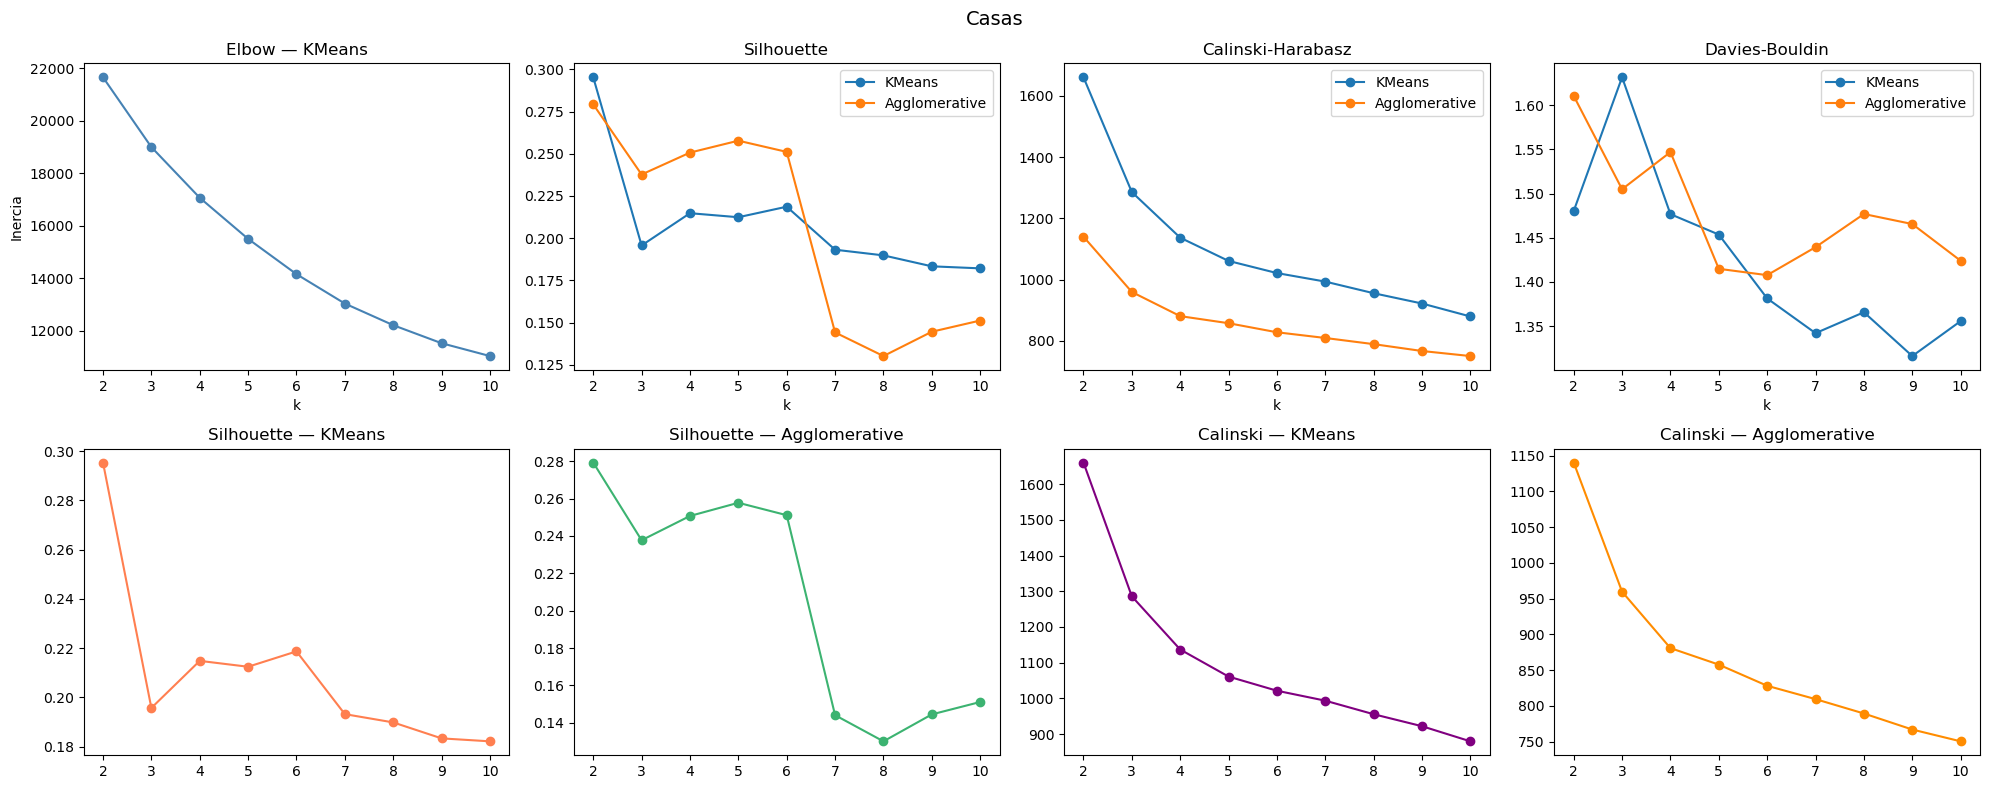

,k,silhouette_km,calinski_km,davies_km,silhouette_agg,calinski_agg,davies_agg
0,2,0.2953,1660.7254,1.4803,0.2793,1140.1488,1.6107
1,3,0.1957,1285.7756,1.6318,0.2377,959.5278,1.5050
2,4,0.2148,1136.8424,1.4768,0.2507,880.6405,1.5471
3,5,0.2124,1060.9548,1.4536,0.2578,857.5559,1.4149
4,6,0.2186,1021.3011,1.3813,0.2511,827.9628,1.4077
5,7,0.1932,993.4159,1.3420,0.1441,809.2912,1.4394
6,8,0.1898,955.4723,1.3657,0.1301,789.1925,1.4769
7,9,0.1833,921.8581,1.3161,0.1445,766.7759,1.4656
8,10,0.1821,879.4978,1.3557,0.1512,750.2725,1.4240


Mejor Silhouette Casas: k=2
Mejor Calinski Casas: k=2
Mejor Davies Casas: k=9


In [25]:
resultados_casas = evaluar_k(X_casas_train,"Casas")

best_silhouette_C = resultados_casas.loc[resultados_casas["silhouette_km"].idxmax(),"k"]
best_calinski_C = resultados_casas.loc[resultados_casas["calinski_km"].idxmax(),"k"]
best_davies_C = resultados_casas.loc[resultados_casas["davies_km"].idxmin(),"k"]
print(f"Mejor Silhouette Casas: k={best_silhouette_C}")
print(f"Mejor Calinski Casas: k={best_calinski_C}")
print(f"Mejor Davies Casas: k={best_davies_C}")

------------------------------------------
**NOTA**

Comparar, Elegir y justificar eleccion de método definitivo

------------------------------------------

Aunque k=2 es el mejor, no sirve para el objetivo que porque genera una segmentación demasiado agregada. 

Considerando tanto las métricas como las caracteristicas y la interpretabilidad, se van a probar valores mas altos de k para observar los tamaños de los grupos y lo que representarían.

In [26]:
# Distribución K clusters
for k in [4,6,9]:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20)

    labels = km.fit_predict(X_casas_train)

    print(f"\n=== k={k} ===")
    print(pd.Series(labels).value_counts().sort_index())


=== k=4 ===
0     601
1    1976
2    1810
3     459
Name: count, dtype: int64

=== k=6 ===
0     102
1    1741
2     407
3     532
4    1517
5     547
Name: count, dtype: int64

=== k=9 ===
0     748
1     133
2     493
3    1014
4     556
5     512
6     924
7     388
8      78
Name: count, dtype: int64


Con estos resultados se determino que el k=6 es la la alternativa más adecuada, ya que permite distinguir varios perfiles económicos/físicos sin fragmentar tanto el mercado. Entonces ahora se va a analizar el perfil de cada clusters para analizar significado de cada cluster.

In [27]:
# kmeans_casas = KMeans(
#     n_clusters=6,
#     random_state=42,
#     n_init=20)

# df_casas_train["Cluster"] = kmeans_casas.fit_predict(X_casas_train)

# perfil_casas = (df_casas_train.groupby("Cluster")[features_clustering].median())

# perfil_casas

**Ajuste Clustering**

In [28]:
mejor_k_km_casas = 6

### ---- CLUSTERING CASAS
km_casas = KMeans(n_clusters=mejor_k_km_casas, init='k-means++', random_state=42, n_init=10)
df_casas_train['Cluster_KMeans'] = km_casas.fit_predict(X_casas_train)
df_casas_test['Cluster_KMeans']  = km_casas.predict(X_casas_test)  

print("=== DISTRIBUCIÓN DE CLUSTERS — TRAIN ===")
print(f"Casas   KMeans++: {df_casas_train['Cluster_KMeans'].value_counts().sort_index().to_dict()}")

print("\n=== DISTRIBUCIÓN DE CLUSTERS — TEST ===")
print(f"Casas   KMeans++: {df_casas_test['Cluster_KMeans'].value_counts().sort_index().to_dict()}")

=== DISTRIBUCIÓN DE CLUSTERS — TRAIN ===
Casas   KMeans++: {0: 102, 1: 1741, 2: 407, 3: 532, 4: 1517, 5: 547}

=== DISTRIBUCIÓN DE CLUSTERS — TEST ===
Casas   KMeans++: {0: 31, 1: 447, 2: 96, 3: 120, 4: 389, 5: 129}


#### Departamentos

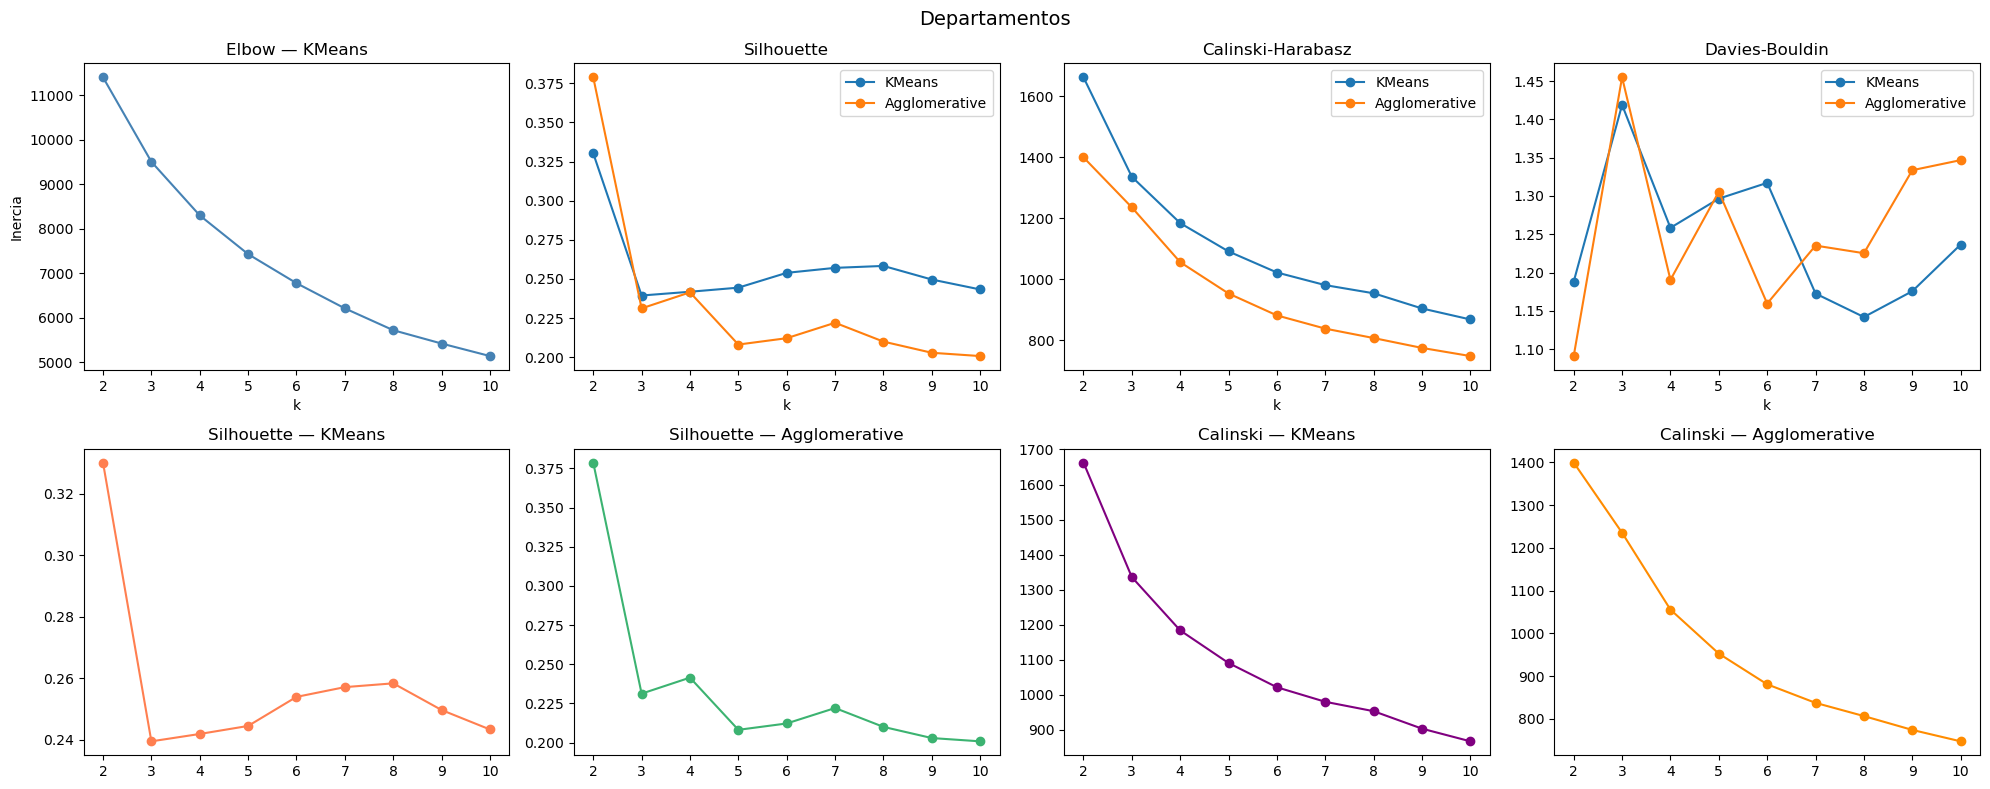

,k,silhouette_km,calinski_km,davies_km,silhouette_agg,calinski_agg,davies_agg
0,2,0.3302,1662.6476,1.1881,0.3788,1399.8296,1.0910
1,3,0.2395,1335.9120,1.4189,0.2312,1235.5814,1.4549
2,4,0.2419,1183.9187,1.2584,0.2415,1055.7259,1.1904
3,5,0.2445,1090.9568,1.2965,0.2081,952.8275,1.3055
4,6,0.2539,1021.8246,1.3171,0.2122,880.9768,1.1595
5,7,0.2571,980.3985,1.1725,0.2221,837.5709,1.2352
6,8,0.2583,953.6038,1.1419,0.2100,806.6739,1.2252
7,9,0.2497,903.7837,1.1756,0.2029,774.2786,1.3336
8,10,0.2433,867.6613,1.2365,0.2008,747.5742,1.3467


Mejor Silhouette Departamentos: k=2
Mejor Calinski Departamentos: k=2
Mejor Davies De|partamentos: k=8


In [29]:
resultados_deptos = evaluar_k(X_deptos_train,"Departamentos")

best_silhouette_D = resultados_deptos.loc[resultados_deptos["silhouette_km"].idxmax(),"k"]
best_calinski_D = resultados_deptos.loc[resultados_deptos["calinski_km"].idxmax(),"k"]
best_davies_D = resultados_deptos.loc[resultados_deptos["davies_km"].idxmin(),"k"]
print(f"Mejor Silhouette Departamentos: k={best_silhouette_D}")
print(f"Mejor Calinski Departamentos: k={best_calinski_D}")
print(f"Mejor Davies De|partamentos: k={best_davies_D}")

------------------------------------------
**NOTA**

Comparar, Elegir y justificar eleccion de método definitivo

------------------------------------------

Al igual que con las casas, k=2 es el mejor, pero no sirve para el objetivo que porque genera una segmentación demasiado agregada. 

Considerando tanto las métricas como las caracteristicas y la interpretabilidad, se van a probar valores mas altos de k para observar los tamaños de los grupos y lo que representarían.

In [30]:
for k in [7,8]:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20)

    labels = km.fit_predict(X_deptos_train)

    print(f"\n=== k={k} ===")
    print(pd.Series(labels).value_counts().sort_index())


=== k=7 ===
0    722
1    485
2    767
3    366
4    907
5      4
6    146
Name: count, dtype: int64

=== k=8 ===
0    147
1    601
2    758
3    659
4    129
5      3
6    480
7    620
Name: count, dtype: int64


En este caso se eligió un k=4 por presentar una distribución más balanceada de observaciones entre clusters y una representación más interpretable del mercado.

In [31]:
kmeans_dpto = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20)

df_deptos_train["Cluster"] = kmeans_dpto.fit_predict(X_deptos_train)

perfil_dpto = (df_deptos_train.groupby("Cluster")[features_clustering].median())

perfil_dpto

,Precio_mercado_zona,bc_Dimensiones,Habitaciones,Baños,Estacionamiento,Pisos
Cluster,,,,,,
0,6.752918,2.359551,1.0,1.0,1.0,1.0
1,6.764239,2.685591,3.0,3.0,2.0,1.0
2,6.716032,2.526379,2.0,2.0,2.0,1.0
3,6.618529,2.401650,2.0,1.0,1.0,1.0


**Ajuste del clustering**

In [32]:
mejor_k_km_deptos = 4

### ---- CLUSTERING DEPARTAMENTOS
km_deptos = KMeans(n_clusters=mejor_k_km_deptos, init='k-means++', random_state=42, n_init=10)
df_deptos_train['Cluster_KMeans'] = km_deptos.fit_predict(X_deptos_train)
df_deptos_test['Cluster_KMeans']  = km_deptos.predict(X_deptos_test)

print("=== DISTRIBUCIÓN DE CLUSTERS — TRAIN ===")
print(f"Deptos  KMeans++: {df_deptos_train['Cluster_KMeans'].value_counts().sort_index().to_dict()}")

print("\n=== DISTRIBUCIÓN DE CLUSTERS — TEST ===")
print(f"Deptos  KMeans++: {df_deptos_test['Cluster_KMeans'].value_counts().sort_index().to_dict()}")

=== DISTRIBUCIÓN DE CLUSTERS — TRAIN ===
Deptos  KMeans++: {0: 854, 1: 591, 2: 1481, 3: 471}

=== DISTRIBUCIÓN DE CLUSTERS — TEST ===
Deptos  KMeans++: {0: 212, 1: 137, 2: 400, 3: 100}


#### Unión de datasets

In [33]:
# ============================================================
# CLUSTER DEFINITIVO KMEANS
# ============================================================
df_casas_train["Cluster"] = ("C" +(df_casas_train["Cluster_KMeans"] + 1).astype(str))
df_casas_test["Cluster"] = ("C" +(df_casas_test["Cluster_KMeans"] + 1).astype(str))

df_deptos_train['Cluster'] = ("D" +(df_deptos_train["Cluster_KMeans"] + 1).astype(str))
df_deptos_test['Cluster']  = ("D" +(df_deptos_test["Cluster_KMeans"] + 1).astype(str))

# Reconstruir train y test completos (casas + departamentos)
df_train_final = pd.concat([df_casas_train, df_deptos_train], axis=0).reset_index(drop=True)
df_test_final  = pd.concat([df_casas_test,  df_deptos_test],  axis=0).reset_index(drop=True)

# Verificación: ningún cluster debe mezclar tipos
print(f"Clusters de casas:         {sorted(df_casas_train['Cluster'].unique())}")
print(f"Clusters de departamentos: {sorted(df_deptos_train['Cluster'].unique())}")
print(f"\nDistribución de clusters en train:")
print(df_train_final.groupby(['Cluster', 'Tipo']).size())

Clusters de casas:         ['C1', 'C2', 'C3', 'C4', 'C5', 'C6']
Clusters de departamentos: ['D1', 'D2', 'D3', 'D4']

Distribución de clusters en train:
Cluster  Tipo        
C1       Casa             102
C2       Casa            1741
C3       Casa             407
C4       Casa             532
C5       Casa            1517
C6       Casa             547
D1       Departamento     854
D2       Departamento     591
D3       Departamento    1481
D4       Departamento     471
dtype: int64


In [34]:
# df_deptos_train[
#     df_deptos_train["Cluster"] == "D2"
# ]

# df_casas_train[
#     df_casas_train["Cluster"] == "C6"
# ]

#### Visualización PCA - TSNE

PCA se utiliza únicamente como herramienta visual exploratoria y no como criterio de validación de los clusters.

Calculando PCA para Casas...


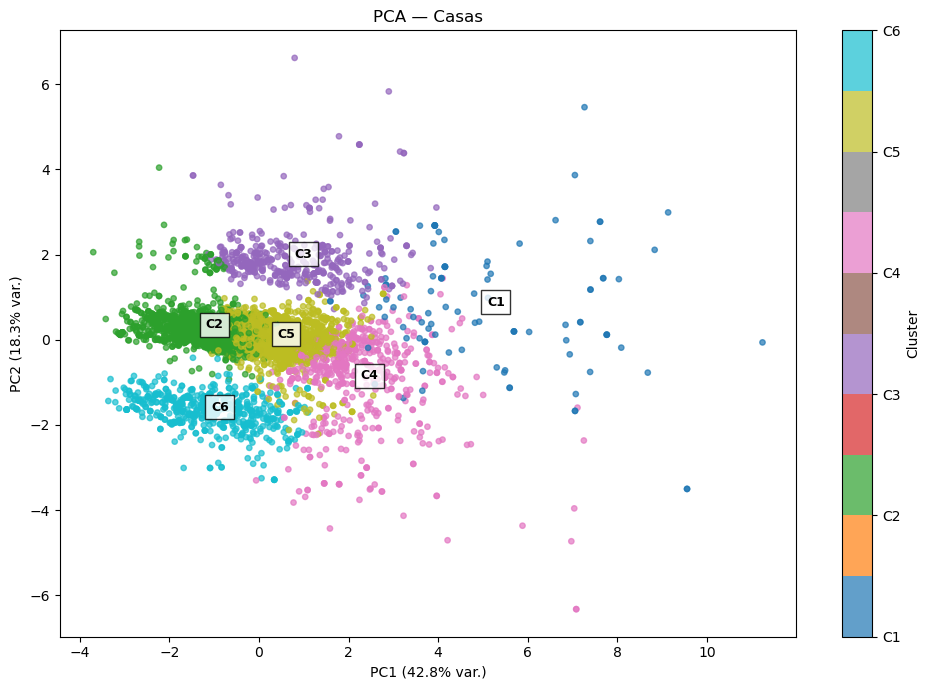

Varianza explicada total: 61.07%
Calculando PCA para Departamentos...


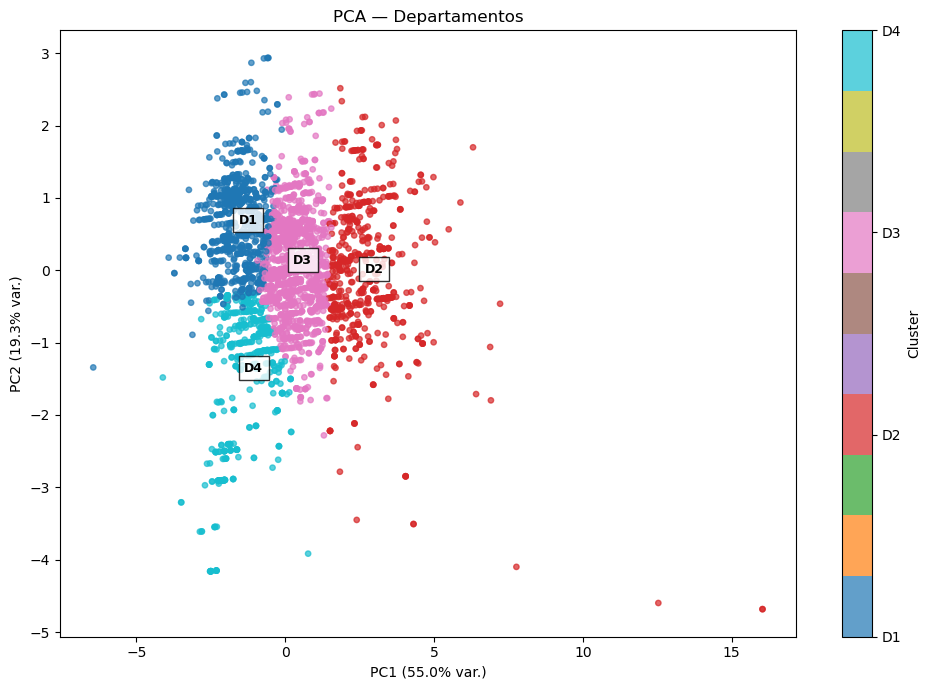

Varianza explicada total: 74.37%


In [35]:
def visualizar_pca(X_train, df_sub, nombre):

    print(f"Calculando PCA para {nombre}...")

    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_train)

    # --- Extraer número del cluster para colorear (funciona con "C1","C2"... y "D1","D2"...)
    cluster_labels = df_sub["Cluster"].unique()
    cluster_sorted = sorted(cluster_labels)
    cluster_to_num = {label: i for i, label in enumerate(cluster_sorted)}
    cluster_num    = df_sub["Cluster"].map(cluster_to_num)

    plt.figure(figsize=(10, 7))

    scatter = plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=cluster_num,          # ahora sí son números
        cmap="tab10",
        alpha=0.7,
        s=15)

    for cluster in cluster_sorted:

        idx = df_sub["Cluster"] == cluster

        plt.text(
            X_pca[idx, 0].mean(),
            X_pca[idx, 1].mean(),
            cluster,            
            fontsize=9,
            weight="bold",
            bbox=dict(facecolor="white", alpha=0.8))

    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)")
    plt.title(f"PCA — {nombre}")

    # Colorbar con etiquetas legibles
    cbar = plt.colorbar(scatter)
    cbar.set_ticks(range(len(cluster_sorted)))
    cbar.set_ticklabels(cluster_sorted)
    cbar.set_label("Cluster")

    plt.tight_layout()
    plt.show()

    print(f"Varianza explicada total: {sum(pca.explained_variance_ratio_)*100:.2f}%")

visualizar_pca(X_casas_train,  df_casas_train,  "Casas")
visualizar_pca(X_deptos_train, df_deptos_train, "Departamentos")

t-SNE está diseñado para proyectar datos de alta dimensión a 2D intentando preservar vecindades locales y de esta manera ver como se distriuyen los clusters

Calculando t-SNE para Casas...


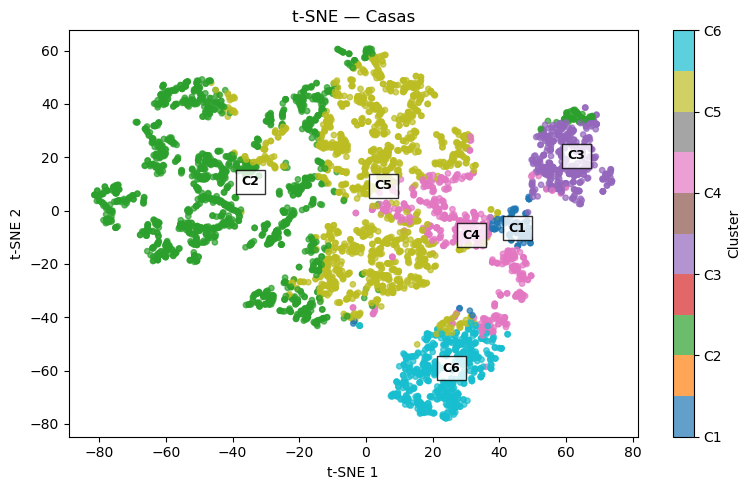

Calculando t-SNE para Departamentos...


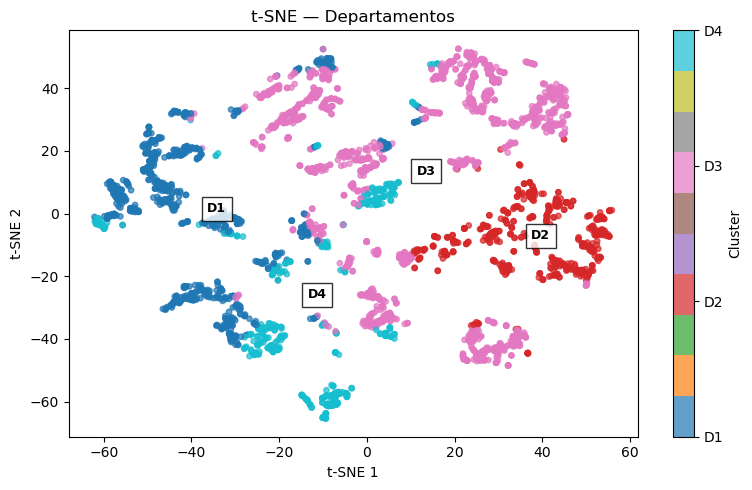

In [36]:
def visualizar_tsne(X_train, df_sub, nombre):

    print(f"Calculando t-SNE para {nombre}...")

    tsne = TSNE(n_components=2, perplexity=40, random_state=42)
    X_tsne = tsne.fit_transform(X_train)

    # Mismo patrón que PCA
    cluster_sorted = sorted(df_sub["Cluster"].unique())
    cluster_to_num = {label: i for i, label in enumerate(cluster_sorted)}
    cluster_num    = df_sub["Cluster"].map(cluster_to_num)

    plt.figure(figsize=(8, 5))
    scatter = plt.scatter(
        X_tsne[:, 0],
        X_tsne[:, 1],
        c=cluster_num,
        cmap="tab10",
        alpha=0.7,
        s=15)

    for cluster in cluster_sorted:

        idx = df_sub["Cluster"] == cluster

        plt.text(
            X_tsne[idx, 0].mean(),
            X_tsne[idx, 1].mean(),
            cluster,           
            fontsize=9,
            weight="bold",
            bbox=dict(facecolor="white", alpha=0.8))

    plt.title(f"t-SNE — {nombre}")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")

    cbar = plt.colorbar(scatter)
    cbar.set_ticks(range(len(cluster_sorted)))
    cbar.set_ticklabels(cluster_sorted)
    cbar.set_label("Cluster")

    plt.tight_layout()
    plt.show()

visualizar_tsne(X_casas_train,  df_casas_train,  "Casas")
visualizar_tsne(X_deptos_train, df_deptos_train, "Departamentos")

#### Perfil de clusters

In [37]:
### ---- INTERPRETABILIDAD DE CLUSTERS
# Resumen por cluster usando valores originales
cluster_summary = (
    df_train_final
    .groupby('Cluster')[[
        'Precio', 'Dimensiones','Habitaciones',
        'Baños','Estacionamiento','Pisos',
    ]]
    .median().round(2))

cluster_summary['N_registros'] = df_train_final['Cluster'].value_counts().sort_index()

print("=== RESUMEN DE CLUSTERS ===")

for cluster_id, row in cluster_summary.iterrows():
    print(f"\nCluster {cluster_id}:")
    print(f"  - Precio mediano: {row['Precio']:,.2f}")
    print(f"  - Dimensiones medianas: {row['Dimensiones']:,.2f} m2")
    print(f"  - Habitaciones: {row['Habitaciones']}, Baños: {row['Baños']}")
    print(f"  - Estacionamientos: {row['Estacionamiento']}, Pisos: {row['Pisos']}")
    print(f"  - Registros en cluster: {row['N_registros']}")

=== RESUMEN DE CLUSTERS ===

Cluster C1:
  - Precio mediano: 25,725,000.00
  - Dimensiones medianas: 879.50 m2
  - Habitaciones: 8.0, Baños: 8.5
  - Estacionamientos: 3.0, Pisos: 2.0
  - Registros en cluster: 102.0

Cluster C2:
  - Precio mediano: 2,700,000.00
  - Dimensiones medianas: 125.00 m2
  - Habitaciones: 3.0, Baños: 2.0
  - Estacionamientos: 2.0, Pisos: 2.0
  - Registros en cluster: 1741.0

Cluster C3:
  - Precio mediano: 7,200,000.00
  - Dimensiones medianas: 250.00 m2
  - Habitaciones: 4.0, Baños: 4.0
  - Estacionamientos: 2.0, Pisos: 3.0
  - Registros en cluster: 407.0

Cluster C4:
  - Precio mediano: 15,250,000.00
  - Dimensiones medianas: 880.00 m2
  - Habitaciones: 4.0, Baños: 5.0
  - Estacionamientos: 5.0, Pisos: 2.0
  - Registros en cluster: 532.0

Cluster C5:
  - Precio mediano: 7,250,000.00
  - Dimensiones medianas: 287.68 m2
  - Habitaciones: 3.0, Baños: 3.0
  - Estacionamientos: 2.0, Pisos: 2.0
  - Registros en cluster: 1517.0

Cluster C6:
  - Precio mediano: 3,000

La segmentación permitió identificar distintos niveles de mercado inmobiliario. Estos clusters servirán como variable explicativa en la etapa de predicción, permitiendo capturar diferencias estructurales en el comportamiento de los precios.

#### Estabilidad

In [38]:
sil_train = silhouette_score(X_casas_train, df_casas_train['Cluster_KMeans'])
sil_test  = silhouette_score(X_casas_test,  df_casas_test['Cluster_KMeans'])
print(f"Silhouette Casas — Train: {sil_train:.4f} | Test: {sil_test:.4f}")

Silhouette Casas — Train: 0.2186 | Test: 0.2274


In [39]:
# Exportar data definitivo para utilizarlo en el documento de predicción
df_train_final.to_excel("clusters_inmuebles.xlsx", index=False)

# Conclusión

La segmentación no se realizó exclusivamente a partir de variables de mercado ni únicamente mediante atributos físicos de las propiedades. Se utilizaron ambos tipos de variables con el propósito de identificar segmentos que reflejaran simultáneamente las condiciones comerciales y las características de los inmuebles, permitiendo obtener grupos más representativos y útiles para la toma de decisiones inmobiliarias.

In [40]:

# # ==================================================
# # Coordenadas por estado
# # ==================================================

# coords_estados = {
#     "Aguascalientes": [21.8823, -102.2826],
#     "Baja California": [32.6519, -115.4689],
#     "Baja California Sur": [24.1426, -110.3128],
#     "Campeche": [19.8301, -90.5349],
#     "Coahuila": [25.4380, -100.9730],
#     "Colima": [19.2433, -103.7250],
#     "Chiapas": [16.7569, -93.1292],
#     "Chihuahua": [28.6320, -106.0691],
#     "Ciudad de México": [19.4326, -99.1332],
#     "Durango": [24.0277, -104.6532],
#     "Guanajuato": [21.0190, -101.2574],
#     "Guerrero": [17.5506, -99.5058],
#     "Hidalgo": [20.0911, -98.7624],
#     "Jalisco": [20.6597, -103.3496],
#     "México": [19.3574, -99.0682],
#     "Michoacán": [19.5665, -101.7068],
#     "Morelos": [18.6813, -99.1013],
#     "Nayarit": [21.7514, -104.8455],
#     "Nuevo León": [25.6866, -100.3161],
#     "Oaxaca": [17.0594, -96.7216],
#     "Puebla": [19.0414, -98.2063],
#     "Querétaro": [20.5888, -100.3899],
#     "Quintana Roo": [21.1619, -86.8515],
#     "San Luis Potosí": [22.1565, -100.9855],
#     "Sinaloa": [24.8091, -107.3940],
#     "Sonora": [29.0729, -110.9559],
#     "Tabasco": [17.9869, -92.9303],
#     "Tamaulipas": [25.4380, -99.9440],
#     "Tlaxcala": [19.3182, -98.1996],
#     "Veracruz": [19.1738, -96.1342],
#     "Yucatán": [20.9674, -89.5926],
#     "Zacatecas": [22.7709, -102.5833]
# }

# # ==================================================
# # Limpieza
# # ==================================================

# df = df_train_final.copy()

# df["Estado"] = (
#     df["Estado"]
#     .astype(str)
#     .str.strip()
# )

# # ==================================================
# # Conteo total por estado
# # ==================================================

# conteo_estado = df["Estado"].value_counts()

# # ==================================================
# # Distribución porcentual
# # ==================================================

# dist = (
#     df.groupby(["Estado", "Cluster"])
#       .size()
#       .unstack(fill_value=0)
# )

# dist_pct = (
#     dist.div(dist.sum(axis=1), axis=0)
#         .round(3) * 100
# )

# # ==================================================
# # Cluster dominante (solo para color)
# # ==================================================

# cluster_dominante = dist.idxmax(axis=1)

# # ==================================================
# # Colores
# # ==================================================

# colores = {
#     "C1":"red",
#     "C2":"blue",
#     "C3":"green",
#     "C4":"purple",
#     "C5":"orange",
#     "C6":"brown",
#     "D1":"pink",
#     "D2":"black",
#     "D3":"gray",
#     "D4":"gold"
# }

# # ==================================================
# # Crear mapa
# # ==================================================

# m = folium.Map(
#     location=[23.6345, -102.5528],
#     zoom_start=5,
#     tiles="CartoDB positron"
# )

# # ==================================================
# # Dibujar estados
# # ==================================================

# for estado in dist_pct.index:

#     if estado not in coords_estados:
#         continue

#     lat, lon = coords_estados[estado]
#     dominante = cluster_dominante[estado]
#     color = colores.get(dominante, "gray")
#     total = conteo_estado[estado]
#     size = max(8, total / 20)

#     # --------------------------------------
#     # Construir popup
#     # --------------------------------------

#     popup = f"""
#     <h4>{estado}</h4>

#     <b>Total propiedades:</b> {total}<br><br>

#     <b>Distribución de clusters:</b><br>
#     """

#     for cluster in dist_pct.columns:
#         porcentaje = dist_pct.loc[estado, cluster]
#         if porcentaje > 0:
#             popup += f"{cluster}: {porcentaje:.1f}%<br>"

#     # --------------------------------------
#     # Marker
#     # --------------------------------------

#     folium.CircleMarker(
#         location=[lat, lon],
#         radius=size,
#         color=color,
#         fill=True,
#         fill_opacity=0.7,
#         popup=folium.Popup(
#             popup,
#             max_width=300
#         )
#     ).add_to(m)

# # ==================================================
# # Guardar
# # ==================================================

# m.save("mapa_clusters.html")

# print("Mapa generado correctamente")